In [11]:
import pandas as pd

HUB_METRICS = [
    "hub_topshare_t2_to_t1",
    "hub_antihubshare_t1_wrt_t2",
    "hub_meanfanout_t1_wrt_t2",
    "hub_topshare_t1_to_t2",
    "hub_antihubshare_t2_wrt_t1",
    "hub_meanfanout_t2_wrt_t1",
]
SYMM_HUB_METRICS = ["hub_topshare", "hub_antihubshare", "hub_meanfanout"]

def make_symmetric_hubness_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes your master df that contains directional hubness rows (metric in HUB_METRICS)
    with values stored in df['spearman'].

    Returns a new df with only 3 symmetric metrics:
      - hub_topshare
      - hub_antihubshare
      - hub_meanfanout

    Each symmetric value is the mean of the two directions per
    (language, encoder, definition_gen_model, space, timestamp, other) group.
    """
    dfh = df[df["metric"].isin(HUB_METRICS)].copy()
    dfh["spearman"] = pd.to_numeric(dfh["spearman"], errors="coerce")
    dfh = dfh.dropna(subset=["spearman"])

    # map directional metrics -> symmetric metric name
    mapping = {
        "hub_topshare_t2_to_t1": "hub_topshare",
        "hub_topshare_t1_to_t2": "hub_topshare",

        "hub_antihubshare_t1_wrt_t2": "hub_antihubshare",
        "hub_antihubshare_t2_wrt_t1": "hub_antihubshare",

        "hub_meanfanout_t1_wrt_t2": "hub_meanfanout",
        "hub_meanfanout_t2_wrt_t1": "hub_meanfanout",
    }
    dfh["metric_sym"] = dfh["metric"].map(mapping)

    # group keys: keep whatever defines one experiment setting
    keys = ["language", "encoder", "definition_gen_model", "space", "timestamp", "other", "metric_sym"]

    # average over directions
    out = (
        dfh.groupby(keys)["spearman"]
           .mean()
           .reset_index()
           .rename(columns={"metric_sym": "metric"})
    )

    # keep metric naming consistent with your plotting code
    out["metric"] = out["metric"].astype(str)
    return out

def aggregate_any_effect(df, factor1, factor2):
    return (
        df.groupby([factor1, factor2])["spearman"]
          .agg(["mean", "std", "count"])
          .reset_index()
          .sort_values([factor1, "mean"], ascending=[True, False])
    )


In [ ]:
import numpy as np

def row_zscore_effect_df(effect_df: pd.DataFrame, row_col: str, value_col: str = "mean") -> pd.DataFrame:
    """
    Z-score the 'mean' within each row group (metric), so different scales can share one heatmap.
    Leaves std/count untouched, but std is no longer meaningful in z-scored space (optional).
    """
    df = effect_df.copy()
    def z(x):
        mu = x.mean()
        sd = x.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            return x * 0.0
        return (x - mu) / sd

    df[value_col] = df.groupby(row_col)[value_col].transform(z)
    return df

def order_symmetric_hub_metrics(df_sym: pd.DataFrame) -> pd.DataFrame:
    order = ["hub_topshare", "hub_antihubshare", "hub_meanfanout"]
    df_sym = df_sym.copy()
    df_sym["metric"] = pd.Categorical(df_sym["metric"], categories=order, ordered=True)
    return df_sym.sort_values("metric")hu

In [16]:
df = pd.read_csv('/Users/acw747/Projects/definition_projection/results/hubness.csv')

spaces = ['full','def','pca','rand']

[Count summary] mean=48.00, min=48, max=48


/var/folders/1h/x_p28cm50lj2qwq10bxkz1680000gp/T/ipykernel_59152/53783424.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([factor1, factor2])["spearman"]
/var/folders/1h/x_p28cm50lj2qwq10bxkz1680000gp/T/ipykernel_59152/3200389151.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[value_col] = df.groupby(row_col)[value_col].transform(z)
/Users/acw747/Projects/definition_projection/vis_functions.py:391: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt

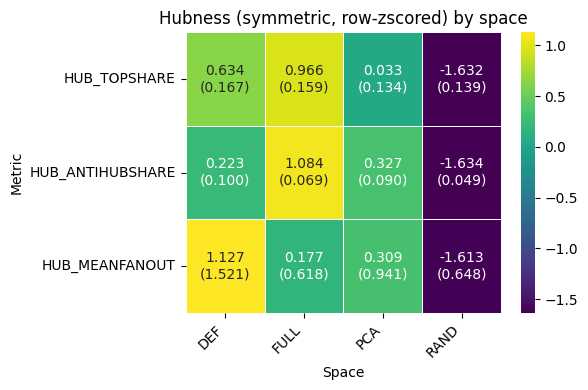

(space                  def      full       pca      rand
 metric                                                  
 hub_topshare      0.633982  0.965672  0.032668 -1.632322
 hub_antihubshare  0.223497  1.083608  0.326647 -1.633752
 hub_meanfanout    1.127246  0.176591  0.309366 -1.613203,
 space                  def      full       pca      rand
 hub_topshare      0.166816  0.159074  0.134231  0.139297
 hub_antihubshare  0.099651  0.069477  0.090318  0.048655
 hub_meanfanout    1.520777  0.617644  0.941324  0.648168
 Average           0.595748  0.282065  0.388625  0.278707)

In [22]:
df_sym = make_symmetric_hubness_df(df)
df_sym = order_symmetric_hub_metrics(df_sym)

hub_effect = aggregate_any_effect(df_sym, "metric", "space")
hub_effect_z = row_zscore_effect_df(hub_effect, row_col="metric")

plot_effect_heatmap(
    hub_effect_z,
    row_col="metric",
    col_col="space",
    title="Hubness (symmetric, row-zscored) by space",
    spaces=spaces
)


In [25]:
import pandas as pd

df_sym = df

KEYS = ["language", "encoder", "definition_gen_model", "space", "timestamp"]

# filter directional dfs (these are already rows from df_sym / df_hubness_raw)
top1  = df_sym[df_sym["metric"] == "hub_topshare_t1_to_t2"].copy()
top2  = df_sym[df_sym["metric"] == "hub_topshare_t2_to_t1"].copy()

anti1 = df_sym[df_sym["metric"] == "hub_antihubshare_t1_wrt_t2"].copy()
anti2 = df_sym[df_sym["metric"] == "hub_antihubshare_t2_wrt_t1"].copy()

fan1  = df_sym[df_sym["metric"] == "hub_meanfanout_t1_wrt_t2"].copy()
fan2  = df_sym[df_sym["metric"] == "hub_meanfanout_t2_wrt_t1"].copy()

# Make sure the values are numeric
for d in (top1, top2, anti1, anti2, fan1, fan2):
    d["spearman"] = pd.to_numeric(d["spearman"], errors="coerce")

# helper: merge and average
def merge_avg(d1, d2, new_col):
    m = d1[KEYS + ["spearman"]].merge(
        d2[KEYS + ["spearman"]],
        on=KEYS,
        how="inner",
        suffixes=("_a", "_b"),
    )
    m[new_col] = (m["spearman_a"] + m["spearman_b"]) / 2.0
    return m[KEYS + [new_col]]

df_hub = merge_avg(top1, top2, "hub_topshare")
df_hub = df_hub.merge(merge_avg(anti1, anti2, "hub_antihubshare"), on=KEYS, how="inner")
df_hub = df_hub.merge(merge_avg(fan1,  fan2,  "hub_meanfanout"),  on=KEYS, how="inner")

# Optional: sanity checks (these should hold for raw shares)
print("topshare min/max:", df_hub["hub_topshare"].min(), df_hub["hub_topshare"].max())
print("antihub min/max:", df_hub["hub_antihubshare"].min(), df_hub["hub_antihubshare"].max())
# meanfanout has no [0,1] bound; it should be >= 1 (unless degenerate)
print("meanfanout min/max:", df_hub["hub_meanfanout"].min(), df_hub["hub_meanfanout"].max())



topshare min/max: 0.0427016844131885 0.6023157894736844
antihub min/max: 0.4273355263157894 0.8542267882697416
meanfanout min/max: 1.7668201342225074 8.979897285501163


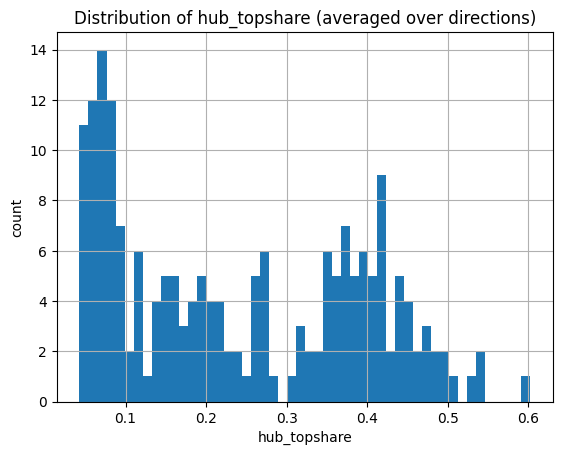

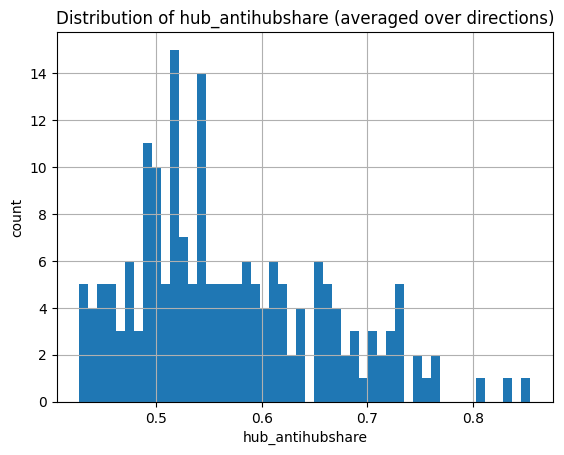

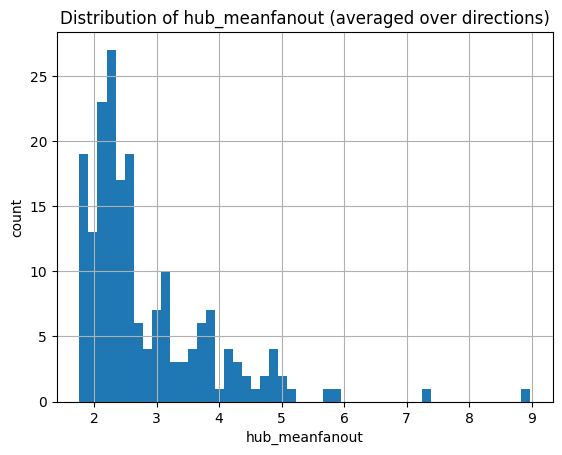

In [26]:
import matplotlib.pyplot as plt

cols = ["hub_topshare", "hub_antihubshare", "hub_meanfanout"]

for c in cols:
    plt.figure()
    df_hub[c].hist(bins=50)
    plt.title(f"Distribution of {c} (averaged over directions)")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()


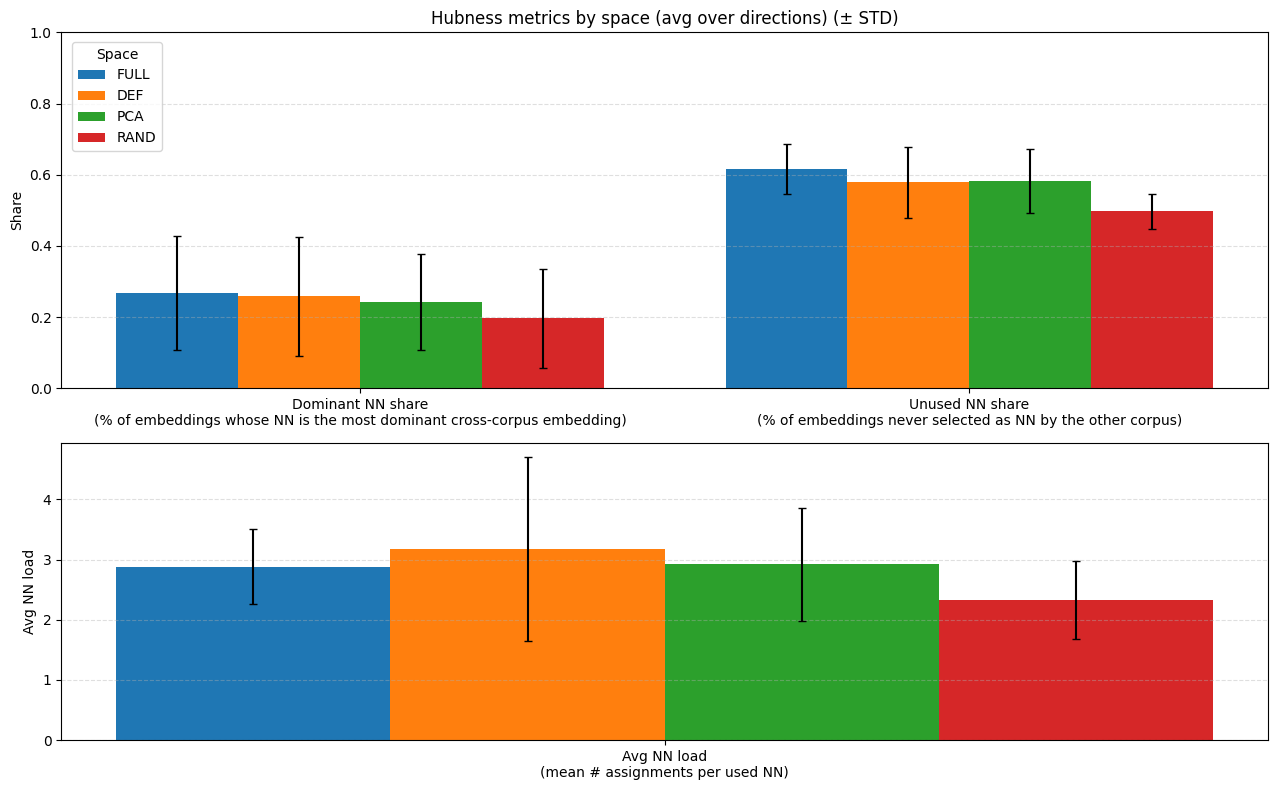

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_hubness_bars_by_metric_separated(
    df_hub: pd.DataFrame,
    *,
    spaces_order=None,
    use_se: bool = False,   # False=STD, True=SE
    figsize=(14, 8),
    title="Hubness metrics by space (avg over directions)",
):
    """
    df_hub columns required:
      - space
      - dominant_nn_share
      - unused_nn_share
      - avg_nn_load

    Produces 1 figure with 2 subplots:
      - Top: dominant_nn_share & unused_nn_share (shares, comparable scale)
      - Bottom: avg_nn_load (different scale)
    """

    share_cols = ["dominant_nn_share", "unused_nn_share"]
    share_labels = [
        "Dominant NN share\n(% of embeddings whose NN is the most dominant cross-corpus embedding)",
        "Unused NN share\n(% of embeddings never selected as NN by the other corpus)",
    ]

    load_col = ["avg_nn_load"]
    load_labels = ["Avg NN load\n(mean # assignments per used NN)"]

    # --- long format + aggregation ---
    all_cols = share_cols + load_col
    long = df_hub.melt(id_vars=["space"], value_vars=all_cols,
                       var_name="metric", value_name="value")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["value"])

    agg = (
        long.groupby(["metric", "space"])["value"]
            .agg(["mean", "std", "count"])
            .reset_index()
    )

    if use_se:
        agg["err"] = agg["std"] / np.sqrt(agg["count"].clip(lower=1))
        err_label = "SE"
    else:
        agg["err"] = agg["std"]
        err_label = "STD"

    # ordering of spaces
    if spaces_order is None:
        spaces = sorted(agg["space"].unique().tolist())
    else:
        spaces = [s for s in spaces_order if s in set(agg["space"])]

    # consistent space->color mapping (matplotlib default cycle)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    space2color = {sp: color_cycle[i % len(color_cycle)] for i, sp in enumerate(spaces)}

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize, sharex=False, gridspec_kw={"height_ratios": [1.2, 1.0]}
    )

    def _plot_group(ax, metrics, labels, ylabel, ylim=None):
        n_metrics = len(metrics)
        n_spaces = len(spaces)
        x = np.arange(n_metrics)

        group_width = 0.8
        bar_width = group_width / max(n_spaces, 1)
        offsets = (np.arange(n_spaces) - (n_spaces - 1) / 2) * bar_width

        for si, sp in enumerate(spaces):
            means, errs = [], []
            for m in metrics:
                row = agg[(agg["metric"] == m) & (agg["space"] == sp)]
                if row.empty:
                    means.append(np.nan)
                    errs.append(np.nan)
                else:
                    means.append(float(row["mean"].iloc[0]))
                    errs.append(float(row["err"].iloc[0]))

            ax.bar(
                x + offsets[si],
                means,
                width=bar_width,
                yerr=errs,
                capsize=3,
                label=sp,
                color=space2color[sp],
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        if ylim is not None:
            ax.set_ylim(*ylim)

    # Top: shares (clamp to [0,1] is usually appropriate)
    _plot_group(
        ax_top,
        share_cols,
        share_labels,
        ylabel="Share",
        ylim=(0.0, 1.0),
    )
    ax_top.set_title(f"{title} (± {err_label})")

    # Bottom: load
    _plot_group(
        ax_bot,
        load_col,
        load_labels,
        ylabel="Avg NN load",
        ylim=None,
    )

    # one legend for the whole figure (spaces)
    handles, labels = ax_top.get_legend_handles_labels()
    fig.legend(
        handles,
        [l.upper() for l in labels],
        title="Space",
        loc="upper left",
        # use colorblind color scheme
        bbox_to_anchor=(0.05, 0.95),
    )

    plt.tight_layout(rect=[0, 0, 0.92, 1])  # leave room for legend
    plt.show()

df_hub = df_hub.rename(columns={
    "hub_topshare": "dominant_nn_share",
    "hub_antihubshare": "unused_nn_share",
    "hub_meanfanout": "avg_nn_load",
})

plot_hubness_bars_by_metric_separated(
    df_hub,
    spaces_order=spaces,
    use_se=False
)


In [51]:
import pandas as pd

HUB_COLS = ["dominant_nn_share", "unused_nn_share", "avg_nn_load"]

def hubness_summary_table(df_hub: pd.DataFrame, spaces_order=None, round_to=3):
    """
    Returns a DataFrame with rows = hubness metrics,
    columns = spaces,
    values = 'mean (std)'.
    """

    # Aggregate mean + std
    agg = (
        df_hub.groupby("space")[HUB_COLS]
              .agg(["mean", "std"])
    )

    # reorder spaces if desired
    if spaces_order is not None:
        spaces = [s for s in spaces_order if s in agg.index]
        agg = agg.loc[spaces]
    else:
        spaces = agg.index.tolist()

    # Build formatted table
    table = pd.DataFrame(index=HUB_COLS, columns=spaces)

    for space in spaces:
        for metric in HUB_COLS:
            mean_val = agg.loc[space, (metric, "mean")]
            std_val  = agg.loc[space, (metric, "std")]

            table.loc[metric, space] = f"{mean_val:.{round_to}f} ({std_val:.{round_to}f})"

    # Pretty metric names (optional)
    table = table.rename(index={
        "dominant_nn_share": "Dominant NN share",
        "unused_nn_share": "Unused NN share",
        "avg_nn_load": "Average NN load",
    })

    return table


In [53]:
hub_table = hubness_summary_table(
    df_hub,
    spaces_order=spaces,
    round_to=3
)

print(hub_table.to_latex()) 


\begin{tabular}{lllll}
\toprule
 & full & def & pca & rand \\
\midrule
Dominant NN share & 0.268 (0.159) & 0.259 (0.167) & 0.243 (0.134) & 0.197 (0.139) \\
Unused NN share & 0.616 (0.069) & 0.578 (0.100) & 0.583 (0.090) & 0.497 (0.049) \\
Average NN load & 2.882 (0.618) & 3.175 (1.521) & 2.923 (0.941) & 2.330 (0.648) \\
\bottomrule
\end{tabular}

